In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/Users/vijaypatidar/vijay/Anshul/deliver time prediction/Food-Delivery-Time-Prediction/data/Food_Delivery_Data.csv')
df.sample(2)

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.dtypes

In [ ]:
df.describe()

In [ ]:
df.describe(include="object")

In [ ]:
# Missing values count
missing_values = df.isnull().sum()
missing_values

In [ ]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})
missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)
missing_df[missing_df['Missing Count']>0]

In [ ]:
df.nunique().sort_values(ascending=False)

In [ ]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:

    print(col)

    print(df[col].astype(str).str.strip().equals(df[col].astype(str)))

In [ ]:
df["Time_taken(min)"].head()

In [ ]:
# df["Time_taken(min)"] = (
#     df["Time_taken(min)"]
#     .str.extract(r"(\d+)")
#     .astype(int)
# )

In [ ]:
df.sample(2)

In [ ]:
# Temporary target conversion for EDA only

target = (
    df["Time_taken(min)"]
    .str.extract(r"(\d+)")
    .astype(int)
)
target.head()

In [ ]:
df["multiple_deliveries"].value_counts()

In [ ]:
df["Delivery_person_Ratings"].value_counts().sort_index().head()

In [ ]:
df["Road_traffic_density"].value_counts()

In [ ]:
df["Weatherconditions"].value_counts()

In [ ]:
df_eda = df.copy()
df_eda["Time_taken(min)"] = (
    df_eda["Time_taken(min)"]
    .str.extract(r"(\d+)")
    .astype(int)
)
df_eda.sample(2)

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_eda,
    x="Delivery_person_Age",
    y="Time_taken(min)"
)
plt.title("Age vs Delivery Time")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_eda,
    x="Delivery_person_Ratings",
    y="Time_taken(min)"
)
plt.title("Ratings vs Delivery Time")
plt.show()

In [ ]:
sns.boxplot(
    data=df_eda,
    x="Type_of_order",
    y="Time_taken(min)"
)
plt.show()

In [ ]:
sns.boxplot(
    data=df_eda,
    x="City",
    y="Time_taken(min)"
)
plt.show()

In [ ]:
sns.boxplot(
    data=df_eda,
    x="Vehicle_condition",
    y="Time_taken(min)"
)
plt.show()

In [ ]:
sns.boxplot(
    data=df_eda,
    x="multiple_deliveries",
    y="Time_taken(min)"
)
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_eda,
    x="Weatherconditions",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None
)
plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (Minutes)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=df_eda,
    x="Festival",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.title("Average Delivery Time During Festival")
plt.xlabel("Festival")
plt.ylabel("Average Delivery Time (Minutes)")
plt.show()

In [ ]:
plt.figure(figsize=(6,5))
ax=sns.barplot(
  data=df_eda,
  x='Type_of_vehicle',
  y='Time_taken(min)',
  estimator='mean',
  errorbar=None
)
for container in ax.containers:
  ax.bar_label(container,fmt='%.1f')

In [38]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [39]:
df[["Order_Date", "Time_Orderd", "Time_Order_picked"]].sample(5)

,Order_Date,Time_Orderd,Time_Order_picked
5409,13-02-2022,21:58:13,22:04:12
6907,16-03-2022,23:29:41,23:38:37
14953,25-03-2022,19:34:43,19:48:23
3208,17-03-2022,20:59:19,21:08:49
9653,01-04-2022,8:54:50,9:07:10


In [41]:
df_time = df.copy()
df_time["Order_Date"] = pd.to_datetime(
    df_time["Order_Date"],
    dayfirst=True,
    errors="coerce"
)

In [79]:
df_time["Time_Ordered"] = pd.to_datetime(
    df_time["Time_Ordered"],
    format="%H:%M:%S",
    errors="coerce"
)

df_time["Time_Order_picked"] = pd.to_datetime(
    df_time["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

In [81]:
df_time["Pickup_Delay"].describe()

count    40353.000000
mean       -16.037530
std        189.788237
min      -1439.500000
25%          5.516667
50%          9.283333
75%         13.133333
max         19.883333
Name: Pickup_Delay, dtype: float64

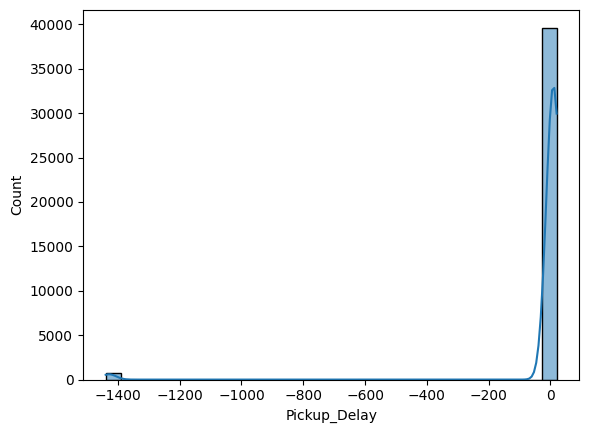

In [82]:
sns.histplot(df_time["Pickup_Delay"], bins=30, kde=True)
plt.show()

In [84]:
df_time["Order_Hour"] = df_time["Time_Ordered"].dt.hour

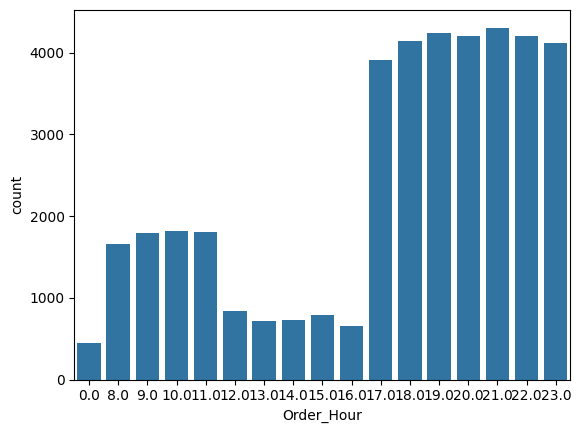

In [85]:
sns.countplot(data=df_time, x="Order_Hour")
plt.show()

In [86]:
df_time["Month"] = df_time["Order_Date"].dt.month
df_time["Day_of_Week"] = df_time["Order_Date"].dt.day_name()

In [87]:
df_time["Weekend"] = df_time["Day_of_Week"].isin(
    ["Saturday", "Sunday"]
)

In [88]:
def rush_hour(hour):
    if 7 <= hour <= 10:
        return "Breakfast"
    elif 12 <= hour <= 15:
        return "Lunch"
    elif 18 <= hour <= 22:
        return "Dinner"
    return "Normal"

df_time["Rush_Hour"] = df_time["Order_Hour"].apply(rush_hour)

In [89]:
df.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
39472,0x2f60,MYSRES08DEL02,25.0,4.5,12.297954,76.665169,12.347954,76.715169,30-03-2022,19:15:57,19:32:54,conditions Stormy,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,(min) 24
41194,0x3f9,SURRES20DEL01,NaN,NaN,21.152760,72.778059,21.192760,72.818059,03-03-2022,NaN,15:32:43,conditions NaN,NaN,3,Buffet,motorcycle,1.0,No,Metropolitian,(min) 33
29984,0x560f,CHENRES04DEL03,33.0,4.0,13.029780,80.208812,13.119780,80.298812,12-03-2022,20:37:36,20:50:59,conditions Cloudy,Jam,1,Drinks,scooter,1.0,No,Metropolitian,(min) 36
36238,0x1ee6,INDORES18DEL02,27.0,5.0,22.753839,75.897429,22.803839,75.947429,05-04-2022,17:48:30,18:00:52,conditions Sunny,Medium,0,Buffet,motorcycle,0.0,No,Metropolitian,(min) 15
25566,0x31d8,RANCHIRES05DEL03,38.0,4.5,23.355164,85.324097,23.385164,85.354097,24-03-2022,0:04:41,0:07:30,conditions Stormy,Low,0,Snack,motorcycle,0.0,No,Urban,(min) 22


In [62]:
df["Time_Orderd"].sample(10)

7535     14:42:41
20685    18:28:10
7659      8:35:37
24141    20:03:16
20783    23:43:48
35602    20:14:42
29901    19:53:39
6429          NaN
23582    19:19:18
32811    23:33:05
Name: Time_Orderd, dtype: object